# 2. lab2. Многослойный персептрон

##Загрузка датасета (вино)

In [ ]:
df_wine = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Wine_Quality/winequality-white.csv', sep=';')

print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
print('\n--- Первые 5 строк ---')
display(df_wine.head())

print('--- Типы данных и наличие значений ---')
print(df_wine.info())
print('\n--- Базовая статистика числовых признаков ---')
display(df_wine.describe())

print("Распределение целевой переменной:")
print(df_wine['quality'].value_counts(normalize=True))

Размер датасета: 8124 строк, 23 столбцов

--- Первые 5 строк ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


--- Типы данных и наличие значений ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None

--- Базовая статистика числовых признаков ---


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


Распределение целевой переменной:
quality
6    0.448755
5    0.297468
7    0.179665
8    0.035729
4    0.033279
3    0.004083
9    0.001021
Name: proportion, dtype: float64


In [ ]:
print(f'Размер до очистки: {df_wine.shape}')

# 1. Заменяем '?' на NaN во всём датасете
df_wine = df_wine.replace('?', np.nan)

# 2. Считаем пропуски до удаления
print(f'Пропусков до очистки: {df_wine.isnull().sum().sum()}')

# 3. Удаляем строки с любыми пропусками
df_clean_wine = df_wine.dropna().reset_index(drop=True)

# 4. Проверяем результат
print(f'Размер после очистки: {df_clean_wine.shape}')
print(f'Удалено строк: {len(df_wine) - len(df_clean_wine)}')

# Проверка на дубликаты
print(f"Дубликатов: {df_clean_wine.duplicated().sum()}")

# 5. Удаление дубликатов
df_clean_wine = df_clean_wine.drop_duplicates()

print(f'Всего удалено {len(df_wine) - len(df_clean_wine)} строк')
display(df_clean_wine.head())


Размер до очистки: (4898, 12)
Пропусков до очистки: 0
Размер после очистки: (4898, 12)
Удалено строк: 0
Дубликатов: 937
Всего удалено 937 строк


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
6,6.2,0.32,0.16,7.0,0.045,30.0,136.0,0.9949,3.18,0.47,9.6,6


## 2.1 Многослойный персептрон-регрессор

In [ ]:
# === 1. Подготовка данных ===
X = df_clean_wine.drop('quality', axis=1).values
y = df_clean_wine['quality'].values.astype(float).reshape(-1, 1)


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

### Ручная реализация

In [ ]:
class MLPRegressor:
    def __init__(self, input_size, hidden_sizes, lr=0.01, epochs=300, clip_value=5.0):
        self.lr = lr
        self.epochs = epochs
        self.clip_value = clip_value
        self.loss_history = []

        self.weights = []
        self.biases = []
        sizes = [input_size] + hidden_sizes + [1]

        for i in range(len(sizes) - 1):
            w = np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(2. / sizes[i])
            w = np.clip(w, -1, 1)
            self.weights.append(w)
            self.biases.append(np.zeros((1, sizes[i+1])))

    def _relu(self, x):
        return np.maximum(0, x)

    def _relu_deriv(self, x):
        return (x > 0).astype(float)

    def _forward(self, X):
        self.z, self.a = [], [X]
        for i in range(len(self.weights) - 1):
            z = self.a[-1] @ self.weights[i] + self.biases[i]
            z = np.clip(z, -500, 500)  # Защита от переполнения в exp/relu
            self.z.append(z)
            self.a.append(self._relu(z))

        z_out = self.a[-1] @ self.weights[-1] + self.biases[-1]
        z_out = np.clip(z_out, -500, 500)
        self.z.append(z_out)
        self.a.append(z_out)
        return z_out

    def _backward(self, y_true):
        m = y_true.shape[0]
        delta = (self.a[-1] - y_true) / m

        for i in range(len(self.weights) - 1, -1, -1):
            # Градиентный клиппинг
            delta = np.clip(delta, -self.clip_value, self.clip_value)

            dw = self.a[i].T @ delta
            db = np.sum(delta, axis=0, keepdims=True)

            # Клиппинг градиентов по весам
            dw = np.clip(dw, -self.clip_value, self.clip_value)
            db = np.clip(db, -self.clip_value, self.clip_value)

            self.weights[i] -= self.lr * dw
            self.biases[i]  -= self.lr * db

            if i > 0:
                delta = (delta @ self.weights[i].T) * self._relu_deriv(self.z[i-1])

    def fit(self, X, y):
        for epoch in range(self.epochs):
            y_pred = self._forward(X)

            # Проверка на NaN до вычисления лосса
            if np.any(np.isnan(y_pred)):
                print(f"Epoch {epoch}: NaN detected! Stopping.")
                break

            loss = np.mean((y_pred - y) ** 2)
            self.loss_history.append(loss)

            self._backward(y)

            if epoch % 50 == 0:
                print(f'Epoch {epoch}: Loss = {loss:.4f}, Weights max = {np.max(np.abs(self.weights[0])):.4f}')

    def predict(self, X):
        return self._forward(X)


### Обучение и оценка

=== Обучение MLP-регрессора (Wine, стабилизированный) ===
Epoch 0: Loss = 2.1612, Weights max = 1.0000
Epoch 50: Loss = 0.9713, Weights max = 0.9951
Epoch 100: Loss = 0.8710, Weights max = 0.9924
Epoch 150: Loss = 0.8263, Weights max = 0.9926
Epoch 200: Loss = 0.7968, Weights max = 0.9932
Epoch 250: Loss = 0.7750, Weights max = 0.9939

=== Метрики на тесте (оригинальный масштаб) ===
R²: 0.1744
MSE: 0.6771
RMSE: 0.8229
MAE: 0.6413


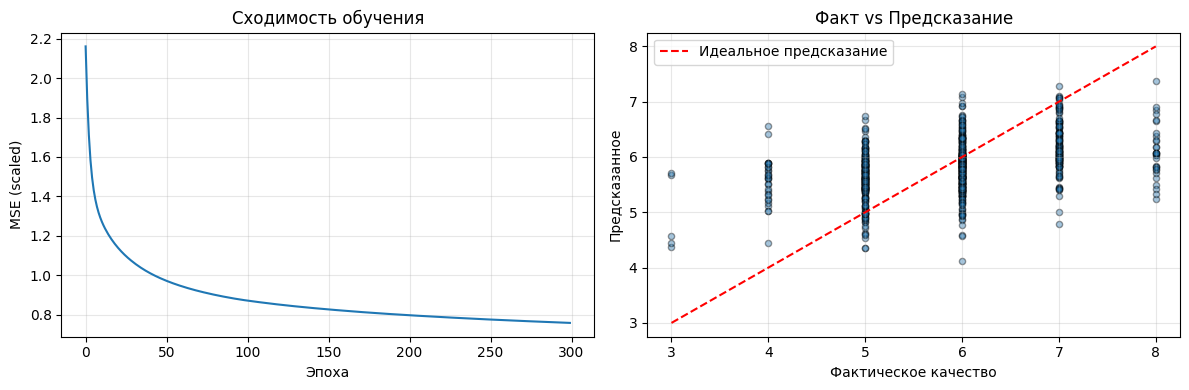

In [ ]:
mlp_reg = MLPRegressor(
    input_size=X_train.shape[1],
    hidden_sizes=[32, 16],
    lr=0.01,
    epochs=300,
    clip_value=1.0
)

print("=== Обучение MLP-регрессора (Wine, стабилизированный) ===")
mlp_reg.fit(X_train, y_train)

# === 4. Оценка ===
y_test_pred_scaled = mlp_reg.predict(X_test)
y_test_pred = scaler_y.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()
y_test_original = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()

print(f"\n=== Метрики на тесте (оригинальный масштаб) ===")
print(f"R²: {r2_score(y_test_original, y_test_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test_original, y_test_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_original, y_test_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_test_original, y_test_pred):.4f}")

# === 5. Визуализация ===
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(mlp_reg.loss_history)
plt.xlabel('Эпоха'); plt.ylabel('MSE (scaled)')
plt.title('Сходимость обучения'); plt.grid(True, alpha=0.3)

# Fact vs Pred
plt.subplot(1, 2, 2)
plt.scatter(y_test_original, y_test_pred, alpha=0.4, edgecolors='black', s=20)
plt.plot([3, 8], [3, 8], 'r--', label='Идеальное предсказание')
plt.xlabel('Фактическое качество'); plt.ylabel('Предсказанное')
plt.title('Факт vs Предсказание'); plt.legend(); plt.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 2.2. Многослойный персептрон-классификатор (MLP-классификатор)


### Ручная реализация

=== Обучение MLP ===
Epoch 0: Loss = 0.8538
Epoch 10: Loss = 0.6510
Epoch 20: Loss = 0.6453
Epoch 30: Loss = 0.6395
Epoch 40: Loss = 0.6335
Epoch 50: Loss = 0.6269
Epoch 60: Loss = 0.6197
Epoch 70: Loss = 0.6118
Epoch 80: Loss = 0.6030
Epoch 90: Loss = 0.5934
Epoch 100: Loss = 0.5828
Epoch 110: Loss = 0.5716
Epoch 120: Loss = 0.5600
Epoch 130: Loss = 0.5479
Epoch 140: Loss = 0.5356
Epoch 150: Loss = 0.5231
Epoch 160: Loss = 0.5105
Epoch 170: Loss = 0.4978
Epoch 180: Loss = 0.4852
Epoch 190: Loss = 0.4726

Точность на train: 0.8941
Точность на test: 0.8884
              precision    recall  f1-score   support

   Съедобный       0.87      0.96      0.91       698
    Ядовитый       0.93      0.77      0.84       431

    accuracy                           0.89      1129
   macro avg       0.90      0.86      0.88      1129
weighted avg       0.89      0.89      0.89      1129



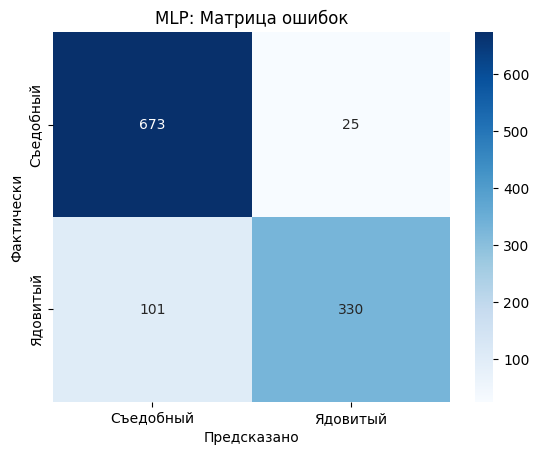

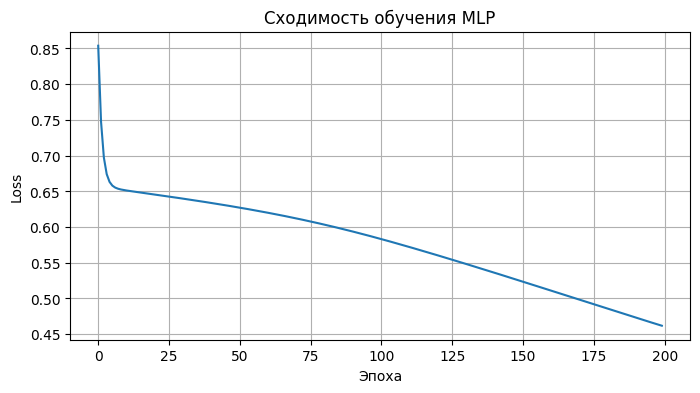

In [ ]:


# === 1. Подготовка данных ===
X = df_final.drop('ядовитый', axis=1).values
y = df_final['ядовитый'].values

y_onehot = np.eye(2)[y]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2, random_state=42, stratify=y
)

# === 2. Реализация MLP ===
class MLPClassifier:
    def __init__(self, input_size, hidden_sizes, output_size, lr=0.01, epochs=100):
        self.lr = lr
        self.epochs = epochs
        self.layers = []
        sizes = [input_size] + hidden_sizes + [output_size]

        # Инициализация весов
        for i in range(len(sizes) - 1):
            w = np.random.randn(sizes[i], sizes[i+1]) * np.sqrt(2. / sizes[i])
            b = np.zeros((1, sizes[i+1]))
            self.layers.append({'w': w, 'b': b})

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def _sigmoid_derivative(self, a):
        return a * (1 - a)

    def _softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _forward(self, X):
        self.activations = [X]
        self.z_values = []

        for i, layer in enumerate(self.layers[:-1]):
            z = self.activations[-1] @ layer['w'] + layer['b']
            self.z_values.append(z)
            a = self._sigmoid(z)
            self.activations.append(a)

        z_out = self.activations[-1] @ self.layers[-1]['w'] + self.layers[-1]['b']
        self.z_values.append(z_out)
        out = self._softmax(z_out)
        self.activations.append(out)
        return out

    def _backward(self, y_true):
        m = y_true.shape[0]
        deltas = []

        # Выходной слой (softmax + cross-entropy)
        delta_out = self.activations[-1] - y_true
        deltas.append(delta_out)

        # Скрытые слои (обратный проход)
        for i in range(len(self.layers) - 1, 0, -1):
            delta = (deltas[0] @ self.layers[i]['w'].T) * self._sigmoid_derivative(self.activations[i])
            deltas.insert(0, delta)

        # Обновление весов
        for i, layer in enumerate(self.layers):
            layer['w'] -= self.lr * (self.activations[i].T @ deltas[i]) / m
            layer['b'] -= self.lr * np.sum(deltas[i], axis=0, keepdims=True) / m

    def _cross_entropy_loss(self, y_pred, y_true):
        return -np.mean(np.sum(y_true * np.log(y_pred + 1e-12), axis=1))

    def fit(self, X, y):
        self.loss_history = []
        for epoch in range(self.epochs):
            y_pred = self._forward(X)
            loss = self._cross_entropy_loss(y_pred, y)
            self.loss_history.append(loss)
            self._backward(y)
            if epoch % 10 == 0:
                print(f'Epoch {epoch}: Loss = {loss:.4f}')

    def predict(self, X):
        probs = self._forward(X)
        return np.argmax(probs, axis=1)

    def score(self, X, y):
        return accuracy_score(np.argmax(y, axis=1), self.predict(X))

# === 3. Обучение модели ===
mlp = MLPClassifier(
    input_size=X_train.shape[1],
    hidden_sizes=[32, 16],
    output_size=2,
    lr=0.1,
    epochs=200
)

print("=== Обучение MLP ===")
mlp.fit(X_train, y_train)

# === 4. Оценка ===
print(f"\nТочность на train: {mlp.score(X_train, y_train):.4f}")
print(f"Точность на test: {mlp.score(X_test, y_test):.4f}")

y_pred = mlp.predict(X_test)
y_test_labels = np.argmax(y_test, axis=1)

print(classification_report(y_test_labels, y_pred, target_names=['Съедобный', 'Ядовитый']))

# Матрица ошибок
cm = confusion_matrix(y_test_labels, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Съедобный', 'Ядовитый'],
            yticklabels=['Съедобный', 'Ядовитый'])
plt.xlabel('Предсказано'); plt.ylabel('Фактически')
plt.title('MLP: Матрица ошибок')
plt.show()

# График потерь
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_history)
plt.xlabel('Эпоха'); plt.ylabel('Loss')
plt.title('Сходимость обучения MLP')
plt.grid(True); plt.show()